In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
%matplotlib inline

# Data_Entry_2017.csv

In [9]:
data_entry_2017_path = 'Data_Entry_2017.csv'
df = pd.read_csv(data_entry_2017_path)
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [10]:
# Number of duplicate rows
duplicates = df.duplicated().sum()

# Total images
total_images = df.shape[0]

# Unique patients
unique_patients = df['Patient ID'].nunique()

# Number of unique findings
unique_findings = df['Finding Labels'].nunique()

# Average images per patient
avg_images_per_patient = total_images / unique_patients

print(f"Number of duplicate rows: {duplicates}")
print(f"Total images: {total_images}")
print(f"Unique patients: {unique_patients}")
print(f"Number of unique findings: {unique_findings}")
print(f"Average images per patient: {avg_images_per_patient:.2f}") # Also indicated through follow up #

Number of duplicate rows: 0
Total images: 112120
Unique patients: 30805
Number of unique findings: 836
Average images per patient: 3.64


In [11]:
df['View Position'].value_counts()

View Position
PA    67310
AP    44810
Name: count, dtype: int64

In [12]:
# Will need cleaning to separate multiple labels
df['Finding Labels'].value_counts()

Finding Labels
No Finding                                                         60361
Infiltration                                                        9547
Atelectasis                                                         4215
Effusion                                                            3955
Nodule                                                              2705
                                                                   ...  
Atelectasis|Consolidation|Edema|Effusion|Infiltration|Pneumonia        1
Atelectasis|Consolidation|Effusion|Emphysema|Mass|Pneumothorax         1
Cardiomegaly|Effusion|Pleural_Thickening|Pneumothorax                  1
Edema|Infiltration|Pneumothorax                                        1
Atelectasis|Consolidation|Mass|Pleural_Thickening|Pneumothorax         1
Name: count, Length: 836, dtype: int64

In [13]:
# Separate Finding Labels into individual labels
all_labels = df['Finding Labels'].str.split('|').explode()
label_counts = all_labels.value_counts()
label_counts

Finding Labels
No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
Name: count, dtype: int64

C:\Users\Khanh Phan\AppData\Local\Temp\ipykernel_35496\332423691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, orient='h', palette=palette)


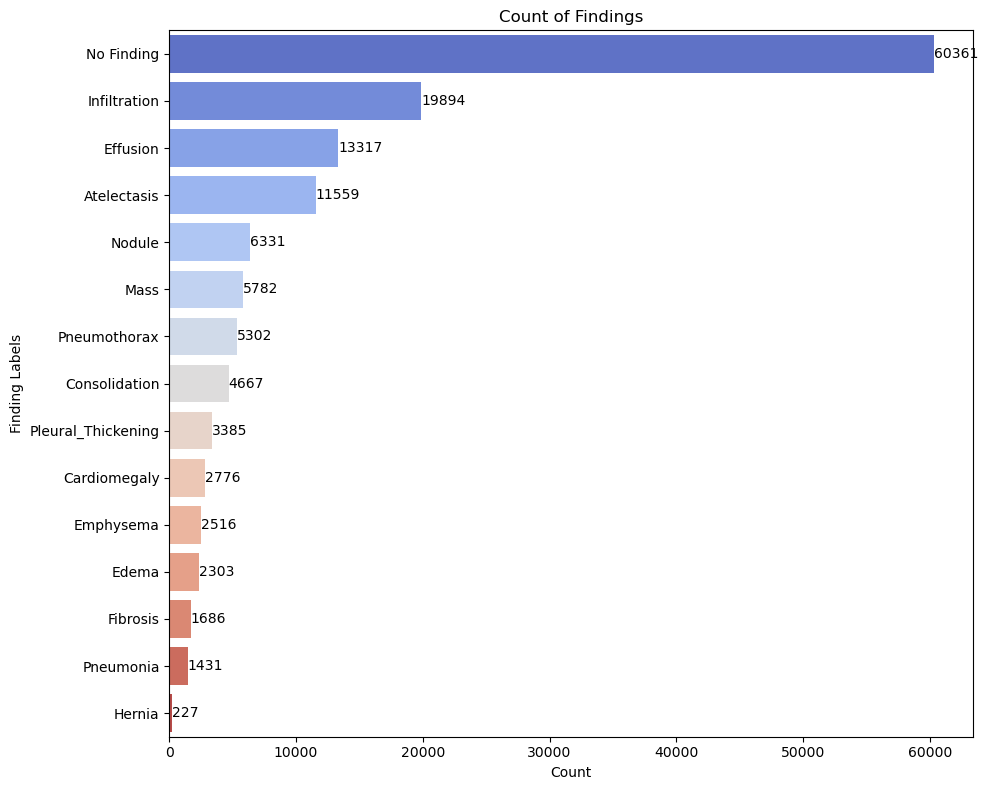

In [14]:
# Note that this only works with number of occurerences, not unique patients with a finding
plt.figure(figsize=(10, 8))

palette = sns.color_palette("coolwarm", n_colors=len(label_counts))

sns.barplot(x=label_counts.values, y=label_counts.index, orient='h', palette=palette)

plt.title('Count of Findings')
plt.xlabel('Count')
plt.ylabel('Finding Labels')

# Add count labels
for i, v in enumerate(label_counts.values):
    plt.text(v, i, str(v), va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

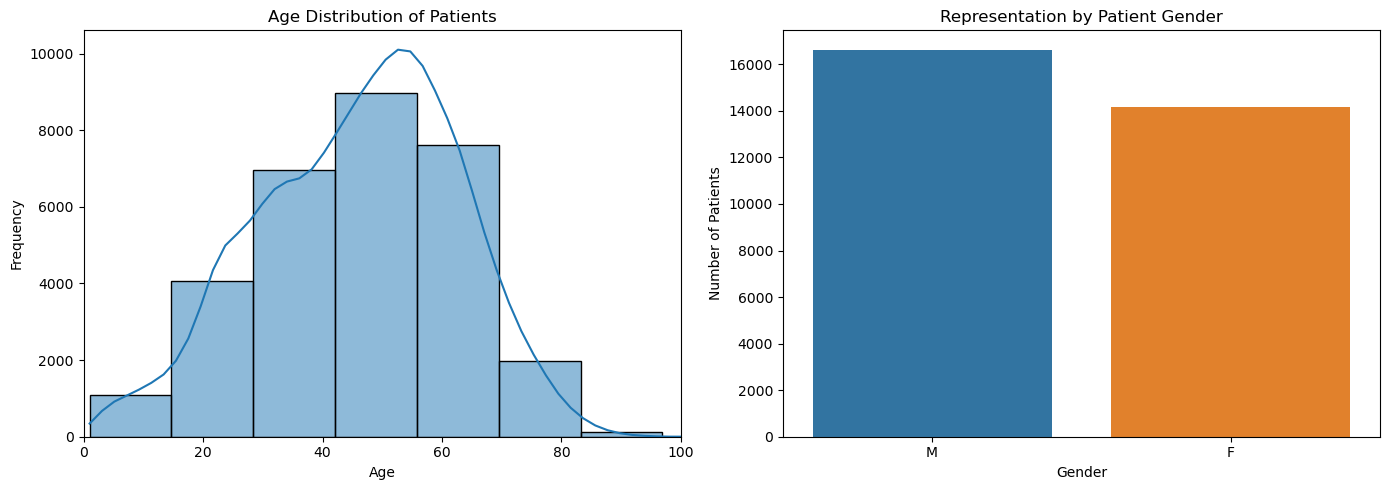

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Distribution
sns.histplot(df.groupby('Patient ID')['Patient Age'].first(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution of Patients')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 100)

# Gender Distribution
sns.countplot(df.groupby('Patient ID').first(), x='Patient Gender', ax=axes[1], hue='Patient Gender')
axes[1].set_title('Representation by Patient Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Number of Patients')

plt.tight_layout()  # Prevents overlapping
plt.show()

# BBox_List_2017.csv

In [16]:
bbox_df = pd.read_csv('BBox_List_2017.csv')
bbox_df.head()

,Image Index,Finding Label,Bbox [x,y,w,h],Unnamed: 6,Unnamed: 7,Unnamed: 8
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,NaN,NaN,NaN
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,NaN,NaN,NaN
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,NaN,NaN,NaN
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,NaN,NaN,NaN
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,NaN,NaN,NaN


In [17]:
# Number of duplicate rows
duplicates_bbox = bbox_df.duplicated().sum()

# Total Bounding Boxes
total_bboxes = bbox_df.shape[0]

# Number of unique findings
unique_findings_bbox = bbox_df['Finding Label'].nunique()


print(f"Number of duplicate rows: {duplicates_bbox}")
print(f"Total Bounding Boxes: {total_bboxes}")
print(f"Number of unique findings: {unique_findings_bbox}")


Number of duplicate rows: 0
Total Bounding Boxes: 984
Number of unique findings: 8


In [18]:
# Number of bounding boxes per image
bbox_df['Image Index'].value_counts()

Image Index
00010277_000.png    4
00008814_010.png    3
00018253_059.png    3
00018427_004.png    3
00020482_032.png    3
                   ..
00000756_001.png    1
00008522_032.png    1
00005532_000.png    1
00030206_013.png    1
00026920_000.png    1
Name: count, Length: 880, dtype: int64

In [24]:
bbox_findings = bbox_df['Finding Label'].value_counts()
bbox_findings

Finding Label
Atelectasis     180
Effusion        153
Cardiomegaly    146
Infiltrate      123
Pneumonia       120
Pneumothorax     98
Mass             85
Nodule           79
Name: count, dtype: int64

C:\Users\Khanh Phan\AppData\Local\Temp\ipykernel_35496\1606320235.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bbox_findings.values, y=bbox_findings.index, orient='h', palette=palette)


<Figure size 1000x800 with 0 Axes>

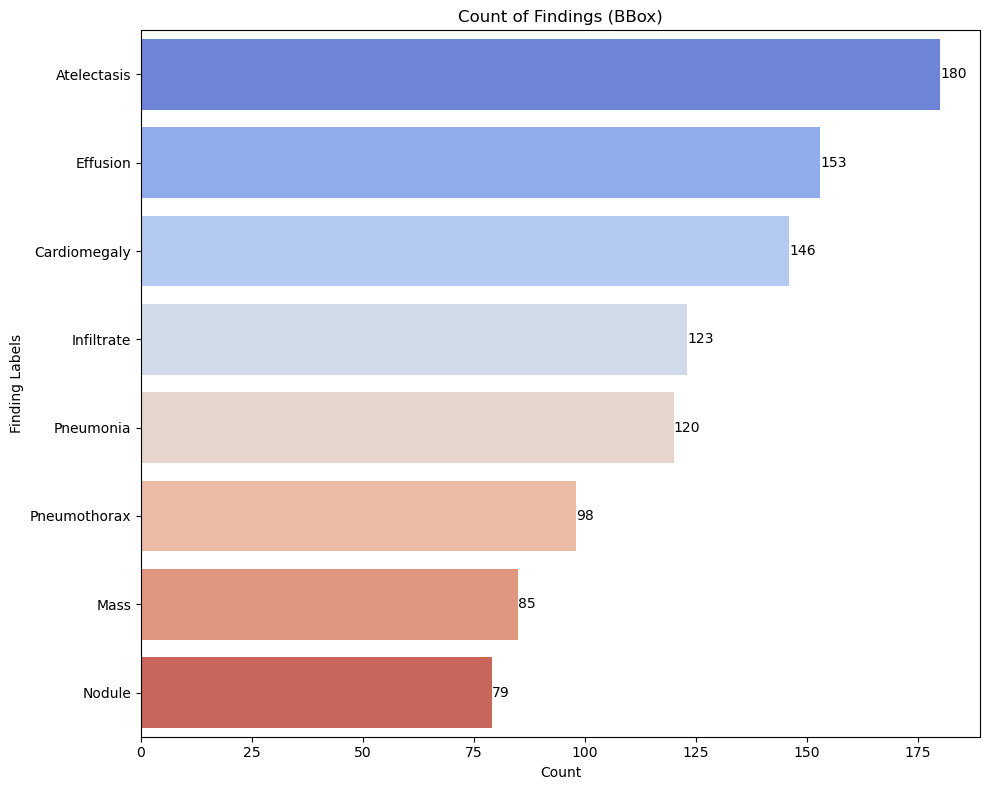

In [25]:
# Note that this only works with number of occurerences, not unique patients with a finding
plt.figure(figsize=(10, 8))

palette = sns.color_palette("coolwarm", n_colors=len(bbox_findings))

sns.barplot(x=bbox_findings.values, y=bbox_findings.index, orient='h', palette=palette)

plt.title('Count of Findings (BBox)')
plt.xlabel('Count')
plt.ylabel('Finding Labels')

# Add count labels
for i, v in enumerate(bbox_findings.values):
    plt.text(v, i, str(v), va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()